In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cufflinks as cf
from IPython.display import display, HTML

# Part 1: Problem framing & EDA

## Required Text

- Dataset description and source
    - UCI's Bank-Marketing Dataset 2011
    - The goal of the dataset is to analyze which types of customers are more likely to subscribe to a term deposit
- Problem type
    - Classification
    - Clustering
- Target variable
    - y (indicates if customer subscribed(yes) or not(no))
- Key input features
    - duration
    - balance
- One-line success criterion

## EDA

In [20]:
df = pd.read_csv(r'D:\Downloads\bank+marketing\bank\bank.csv', sep=';')

In [21]:
df.sample(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
302,56,blue-collar,married,secondary,no,345,yes,no,telephone,22,jul,605,1,-1,0,unknown,no
1610,49,blue-collar,married,primary,no,1019,yes,no,cellular,16,apr,285,5,-1,0,unknown,no
1492,34,technician,married,tertiary,no,5060,yes,no,cellular,21,aug,12,21,-1,0,unknown,no
1090,31,blue-collar,single,primary,no,-502,yes,no,unknown,29,may,76,4,-1,0,unknown,no
1200,58,self-employed,married,secondary,no,1407,yes,no,unknown,30,may,58,1,-1,0,unknown,no
2945,27,student,single,tertiary,no,118,no,no,cellular,25,may,112,1,-1,0,unknown,no
1506,36,entrepreneur,single,secondary,no,475,no,no,cellular,25,jul,141,3,-1,0,unknown,no
4099,33,management,single,tertiary,no,71,no,no,cellular,22,aug,107,6,-1,0,unknown,no
2425,32,unemployed,married,secondary,no,2400,yes,yes,cellular,5,feb,450,3,-1,0,unknown,no
2233,24,services,married,secondary,no,4500,yes,no,cellular,11,may,733,2,-1,0,unknown,yes


In [22]:
df.shape

(4521, 17)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [24]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [25]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


<Axes: xlabel='y', ylabel='count'>

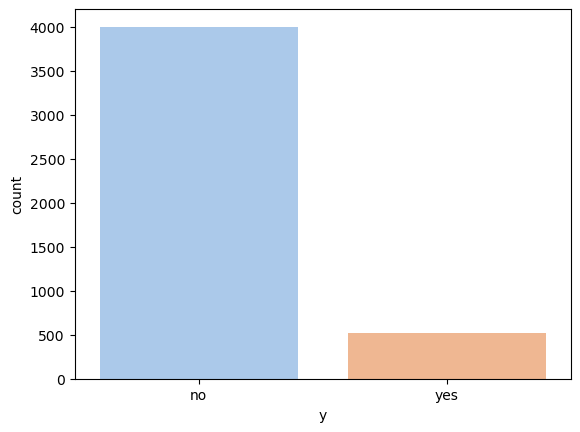

In [26]:
# Target Distribution
sns.countplot(data=df, x='y', hue='y', palette='pastel')

Text(0.5, 1.0, 'Zoomed')

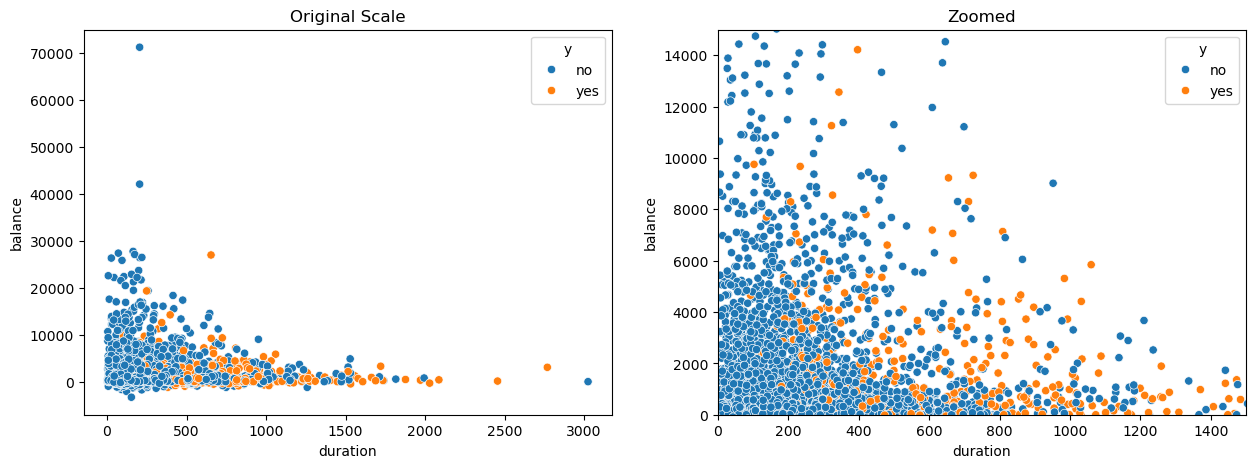

In [27]:
# Feature relationship
fig, ax = plt.subplots(ncols=2, figsize=(15,5))

sns.scatterplot(data=df, x='duration', y='balance', hue='y', ax=ax[0])
ax[0].set_title("Original Scale")

sns.scatterplot(data=df, x='duration', y='balance', hue='y', ax=ax[1])
ax[1].set_xlim(0, 1500)
ax[1].set_ylim(0, 15000)
ax[1].set_title("Zoomed")

<Axes: xlabel='loan', ylabel='count'>

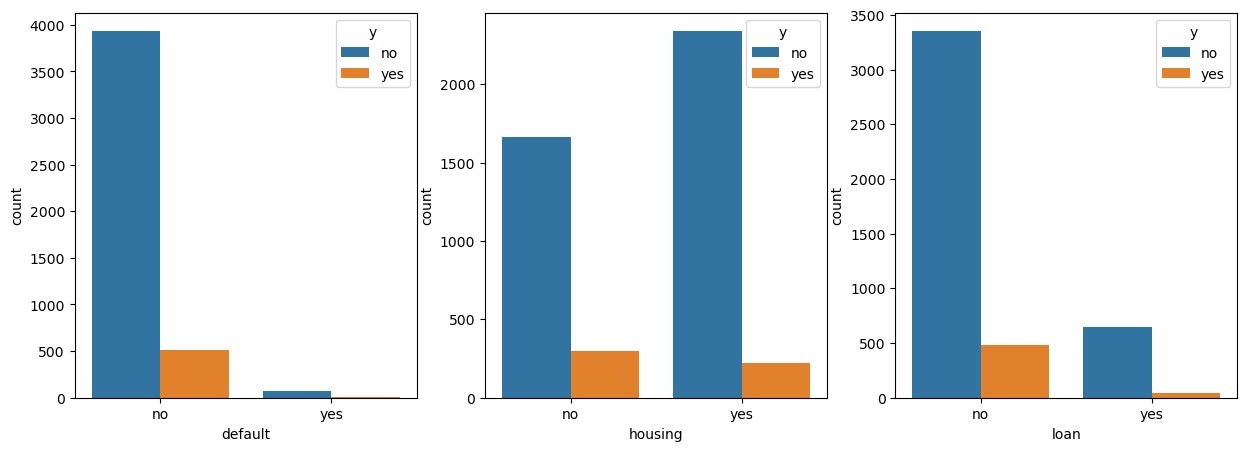

In [28]:
fig, ax = plt.subplots(ncols=3, figsize=(15,5))
sns.countplot(data=df, x='default', hue='y', ax=ax[0])
sns.countplot(data=df, x='housing', hue='y', ax=ax[1])
sns.countplot(data=df, x='loan', hue='y', ax=ax[2])

<Axes: xlabel='poutcome', ylabel='count'>

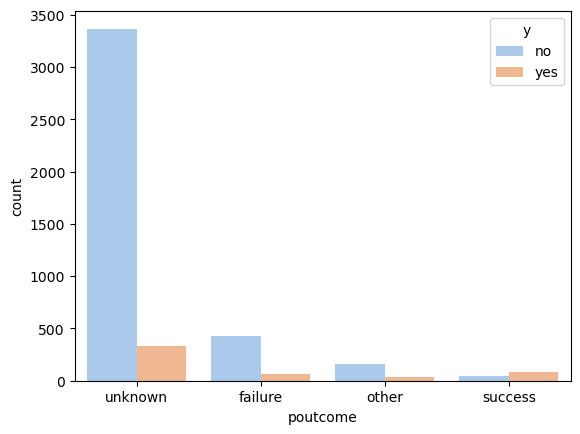

In [29]:
sns.countplot(data=df, x='poutcome', hue='y', palette='pastel')

Text(0, 0.5, 'Average Balance')

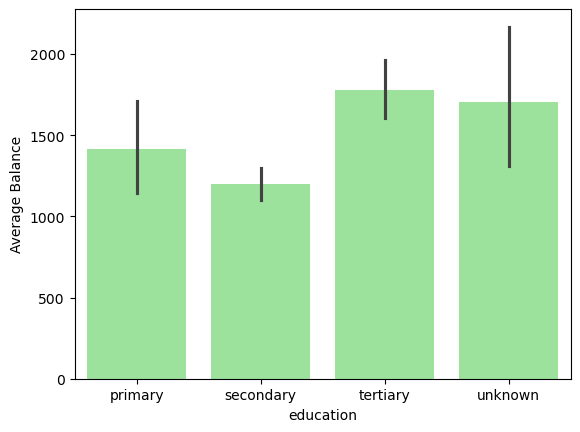

In [30]:
sns.barplot(x='education', y='balance', data=df, estimator=np.mean, color='lightgreen')
plt.ylabel("Average Balance")

In [31]:
# Outlier Check
df['duration'].iplot(kind='box')
df['balance'].iplot(kind='box')

## Observations

- The target distribution is imbalance. 1:7.7 (Yes:No)
- No single strong feature relation found
- Large Outliers present

# Part 2: Preprocessing & data split

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, LabelEncoder, OneHotEncoder

In [33]:
transformer = ColumnTransformer( transformers = [
    ('tnf1', RobustScaler(), ['age', 'balance']),
    ('tnf2', OrdinalEncoder(categories=[['no', 'yes']]*3, dtype= np.int64), ['default', 'loan', 'housing']),
    ('tnf3', OneHotEncoder(drop='first', dtype=np.int64), ['job', 'marital', 'poutcome'])
], remainder = 'drop')

Implementation of train_test_split

In [34]:
def train_test_split_custom (X, y, test_size, seed, stratify) :
    columns = X.columns
    X = np.array(X)
    y = np.array(y)
    n = len(X)

    rng = np.random.default_rng(seed= seed)

    if stratify:
        classes = np.unique(y)

        train_idx = []
        test_idx = []

        for cls in classes:
            cls_idx = np.where(y == cls)[0]
            rng.shuffle(cls_idx)
            n_test = int(len(cls_idx)*test_size)

            test_idx.extend(cls_idx[:n_test])
            train_idx.extend(cls_idx[n_test:])

        rng.shuffle(test_idx)
        rng.shuffle(train_idx)
        
    else:
        indices = np.arange(n)
        rng.shuffle(indices)
        n_test = int(n*test_size)
        
        test_idx = indices[:n_test]
        train_idx = indices[n_test:]

    X_train, X_test, y_train, y_test = X[train_idx], X[test_idx], y[train_idx], y[test_idx]

    X_train = pd.DataFrame(X_train, columns=columns)
    X_test = pd.DataFrame(X_test, columns=columns)

    return X_train, X_test, y_train, y_test

In [35]:
X = df[['age', 'job', 'marital', 'balance', 'default', 'loan', 'housing', 'poutcome']].copy()
y = df['y'].copy()

X_train, X_test, y_train, y_test = train_test_split_custom(X, y, test_size=0.33, seed=0, stratify=True)

X_train_trnfd = transformer.fit_transform(X_train)
X_test_trnfd = transformer.transform(X_test)

le = LabelEncoder()
y_train_trnfd = le.fit_transform(y_train)
y_test_trnfd = le.transform(y_test)

## Observations

- here were no misssing values, hence no need of imputation  
- "Balance" column had large outliers, Robust scaling scaling was chosen to reduce the impact of outliers
- The duration feature causes data leakage because it is known only after the call outcome, therefore it was excluded

# Part 3: Supervised learning (from scratch + baseline)

Implementation of Logistic Regression

In [41]:
import numpy as np

class LogisticRegression_custom:
    
    def __init__(self):
        self.w = None
        self.b = None
        
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
        
    
    def _cost_function(self, X, y):
        m = X.shape[0]
        cost_sum = 0
        
        for i in range(m):
            z = np.dot(self.w, X[i]) + self.b
            g = self._sigmoid(z)
            cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)
        
        return (1/m) * cost_sum
        
    
    def _gradient_function(self, X, y):
        m, n = X.shape
        grad_w = np.zeros(n)
        grad_b = 0
        
        for i in range(m):
            z = np.dot(self.w, X[i]) + self.b
            g = self._sigmoid(z)
            
            grad_b += (g - y[i])
            for j in range(n):
                grad_w[j] += (g - y[i]) * X[i, j]
        
        grad_b = grad_b / m
        grad_w = (1/m) * grad_w
        
        return grad_b, grad_w
        
    
    def fit(self, X, y, alpha=0.01, iterations=1000):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0
        
        for i in range(iterations):
            grad_b, grad_w = self._gradient_function(X, y)
            
            self.w = self.w - alpha * grad_w
            self.b = self.b - alpha * grad_b
            
            if i % 100 == 0:
                cost = self._cost_function(X, y)
                print(f"Iteration {i}: Cost {cost}")
        
    
    def predict(self, X):
        
        m = X.shape[0]
        preds = np.zeros(m)
        
        for i in range(m):
            z = np.dot(self.w, X[i]) + self.b
            g = self._sigmoid(z)
            preds[i] = 1 if g >= 0.5 else 0
        
        return preds

In [42]:
def accuracy_custom(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [48]:
# learning rate = 0.01, iteration = 1000
lr = LogisticRegression_custom()
lr.fit(X_train_trnfd, y_train_trnfd)

Iteration 0: Cost 0.6884990951194236
Iteration 100: Cost 0.4590096439446447
Iteration 200: Cost 0.39437172216530597
Iteration 300: Cost 0.36842523136927124
Iteration 400: Cost 0.3556461028283826
Iteration 500: Cost 0.3484589605609881
Iteration 600: Cost 0.3440429095843934
Iteration 700: Cost 0.3411603872419553
Iteration 800: Cost 0.3391914735754697
Iteration 900: Cost 0.33779182576347994


In [50]:
y_pred_train = lr.predict(X_train_trnfd)
y_pred_test  = lr.predict(X_test_trnfd)

print("Train acc:", accuracy_custom(y_train_trnfd, y_pred_train))
print("Test acc:", accuracy_custom(y_test_trnfd, y_pred_test))

Train acc: 0.8844884488448845
Test acc: 0.8853118712273642


In [57]:
lr_2 = LogisticRegression_custom()
lr_2.fit(X_train_trnfd, y_train_trnfd, 0.5, 500)

Iteration 0: Cost 0.5100921032227675
Iteration 100: Cost 0.3271430833466986
Iteration 200: Cost 0.323144070517327
Iteration 300: Cost 0.32103499553421944
Iteration 400: Cost 0.3197528511703102


In [58]:
y_pred_train_2 = lr_2.predict(X_train_trnfd)
y_pred_test_2  = lr_2.predict(X_test_trnfd)

print("Train acc:", accuracy_custom(y_train_trnfd, y_pred_train_2))
print("Test acc:", accuracy_custom(y_test_trnfd, y_pred_test_2))

Train acc: 0.8917491749174917
Test acc: 0.8933601609657947


In [60]:
lr_3 = LogisticRegression_custom()
lr_3.fit(X_train_trnfd, y_train_trnfd, 0.9, 500)

Iteration 0: Cost 0.42606428766834087
Iteration 100: Cost 0.32369942701914195
Iteration 200: Cost 0.3201846733997457
Iteration 300: Cost 0.3186558678946662
Iteration 400: Cost 0.3178710770377515


In [68]:
y_pred_train_3 = lr_3.predict(X_train_trnfd)
y_pred_test_3  = lr_3.predict(X_test_trnfd)

print("Train acc:", accuracy_custom(y_train_trnfd, y_pred_train_3))
print("Test acc:", accuracy_custom(y_test_trnfd, y_pred_test_3))

Train acc: 0.8940594059405941
Test acc: 0.892018779342723


In [63]:
lr_4 = LogisticRegression_custom()
lr_4.fit(X_train_trnfd, y_train_trnfd, alpha=1.5, iterations=1000)

Iteration 0: Cost 0.3732359824120501
Iteration 100: Cost 0.3209933550729985
Iteration 200: Cost 0.31833182570094004
Iteration 300: Cost 0.3174246763588294
Iteration 400: Cost 0.31703871667337946
Iteration 500: Cost 0.31685453044454065
Iteration 600: Cost 0.31676115981616315
Iteration 700: Cost 0.31671215349460985
Iteration 800: Cost 0.3166858185534153
Iteration 900: Cost 0.31667138820476887


In [70]:
y_pred_train_4 = lr_4.predict(X_train_trnfd)
y_pred_test_4  = lr_4.predict(X_test_trnfd)

print("Train acc:", accuracy_custom(y_train_trnfd, y_pred_train_4))
print("Test acc:", accuracy_custom(y_test_trnfd, y_pred_test_4))

Train acc: 0.8917491749174917
Test acc: 0.8926894701542589


In [73]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression()
sk_model.fit(X_train_trnfd, y_train_trnfd)

y_pred_sk = sk_model.predict(X_test_trnfd)
print("sklearn Test acc:", accuracy_custom(y_test_trnfd, y_pred_sk))

sklearn Test acc: 0.8926894701542589


In [76]:
# because the accuracy of sklearn model and custom model is exactly same to last decimal digit
print("Custom weights:", lr_4.w)
print("Sklearn weights:", sk_model.coef_[0])
print("Weight difference:", np.abs(lr_4.w - sk_model.coef_[0]))

print("\nCustom bias:", lr_4.b)
print("Sklearn bias:", sk_model.intercept_[0])
print("Bias difference:", np.abs(lr_4.b - sk_model.intercept_[0]))

Custom weights: [ 0.13237366  0.02464927 -0.10503954 -0.68672583 -0.4868163  -0.67389675
 -0.58979707  0.0465594  -0.00543508  0.46782048 -0.01430898 -0.35617844
  0.35606989 -0.51179082 -0.49492129 -0.07528329 -0.48832012 -0.14436952
  0.49467231  2.50204492 -0.32118142]
Sklearn weights: [ 0.13865467  0.02509983 -0.08732834 -0.66046513 -0.48558553 -0.63074453
 -0.52496963  0.06132107  0.01902587  0.46585861  0.00449581 -0.31359641
  0.35015414 -0.46981489 -0.43028905 -0.04174344 -0.46554784 -0.12004783
  0.449369    2.3389296  -0.35898931]
Weight difference: [0.00628101 0.00045056 0.01771121 0.0262607  0.00123076 0.04315222
 0.06482744 0.01476167 0.02446095 0.00196187 0.01880478 0.04258203
 0.00591575 0.04197592 0.06463224 0.03353985 0.02277228 0.0243217
 0.04530331 0.16311533 0.03780788]

Custom bias: -1.129026420999344
Sklearn bias: -1.1380092400280837
Bias difference: 0.008982819028739764


## Observations

- Algorithm had negligible sensitivity towards parameters like learning rate and number of iterations